## Notebook 4: Impact Functions

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
SUMMARY OF NOTEBOOK
</blockquote>

In [17]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [18]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [19]:
cfg  = C.get("cfg")     # dict loaded from YAML

**from Notebook 3**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from climada.hazard import Hazard
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

plt.rcParams.update({"figure.dpi": 130})

# loading hazard and exposure produced in Notebook 3
haz_path = INT / f"hazard_HEAT_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"

H   = Hazard.from_hdf5(haz_path)

exp = Exposures.from_hdf5(exp_path)

# we'll reuse this a lot:
years = [int(y) for y in H.event_id.tolist()]

print("Hazard events:", years)
print("Exposure rows:", len(exp.gdf))
print(exp.gdf.head())

Hazard events: [2030, 2050, 2070, 2090, 2100]
Exposure rows: 74469
      value age_group  impf_HEAT                  geometry
0  0.210637       <15          1  POINT (8.99336 44.54418)
1  0.122708       <15          1  POINT (8.99446 44.54418)
2  0.137117       <15          1  POINT (8.99555 44.54418)
3  0.117362       <15          1  POINT (8.99665 44.54418)
4  0.151306       <15          1  POINT (8.99775 44.54418)


Age-group population totals from exp (because later we do per-100k by group)

In [21]:
age_pop = (
    exp.gdf.groupby("age_group")["value"]
    .sum()
    .astype(float)
    .sort_index()
)
print("Population by age group on WBGT grid:")
print(age_pop)
print("Total population on WBGT grid:", float(age_pop.sum()))

Population by age group on WBGT grid:
age_group
15-64    333251.200034
65+      187891.441338
<15       52792.300351
Name: value, dtype: float64
Total population on WBGT grid: 573934.9417225594


> **Impact Funtions in Climada:**
> - how intensity → damage
> - “intensity” = how many very hot WBGT days per year in that pixel (e.g. 45 days > 28°C)
> - “Damage” = heat mortality per person (deaths per person per year) (MDD: mean damage degree)
> - We want three different curves: `&lt;15`, 15–64, 65+
>   - intuition : older people die more of heat, even at slightly milder
>     conditions. Kids are vulnerable but absolute numbers are tiny because baseline
>     mortality is already very low. Working-age adults are in the middle.
> - Defining a threshold `tau_days` where risk kicks in, and a curvature `gamma` that says how fast mortality explodes when we get more and more extreme heat. Smaller `tau` / higher `gamma` = more fragile.

**helpers**

In [22]:
def subset_exposure_by_age(exp_obj, age_label):
    """
    Return a new Exposures with only rows for one age group.
    This lets us run impacts for each age group separately.
    """
    mask = exp_obj.gdf["age_group"] == age_label
    if not mask.any():
        return None
    sub = Exposures()
    sub.set_gdf(exp_obj.gdf.loc[mask].copy())
    sub.value_unit = exp_obj.value_unit
    sub.tag = f"{getattr(exp_obj, 'tag', 'exp')} — {age_label}"
    return sub

def run_and_rates(exp_obj, H, if_set_dict):
    """
    Run CLIMADA ImpactCalc for a given exposure, hazard, and IF set.

    Returns:
    - totals: number of heat deaths per event (same order as H.event_id)
    - rate_per_100k: totals divided by that sub-exposure's population * 100k
    """
    ifs = ImpactFuncSet(list(if_set_dict.values()))
    ifs.check()

    imp = ImpactCalc(exp_obj, ifs, H).impact()
    totals = np.ravel(imp.at_event)  # deaths per event (each event is one "year")

    pop_total = float(exp_obj.gdf["value"].sum())
    rate_per_100k = totals / pop_total * 1e5 if pop_total > 0 else np.zeros_like(totals)

    return totals, rate_per_100k

def run_by_age(exp_obj, H, if_set_by_age):
    """
    For each age group, run impact using only that group's exposure rows
    and that group's IF, and return totals and per-100k.
    """
    out = {}
    for age_label, impf in if_set_by_age.items():
        sub = subset_exposure_by_age(exp_obj, age_label)
        if (sub is None) or (float(sub.gdf["value"].sum()) == 0):
            out[age_label] = {
                "totals":   np.zeros(len(H.event_id)),
                "per100k":  np.zeros(len(H.event_id)),
            }
        else:
            totals, rates = run_and_rates(sub, H, {age_label: impf})
            out[age_label] = {"totals": totals, "per100k": rates}
    return out

In [23]:
SLUG = cfg.get("slug", SLUG)
cfg_if = cfg.get("impact_functions", {}) # loading IF para from YAML

In [24]:
AGE_PARAMS = cfg_if.get("age_params")           # dict per age: tau_days, gamma, impf_id, name
BASELINE_PER100K = cfg_if.get("baseline_per100k")  # dict per age: baseline rates
TOTAL_TARGET_PER100K = float(cfg_if["total_target_per100k"])
HEAT_SHARE           = float(cfg_if["heat_share"])
ANCHOR_EVENT         = int(cfg_if["anchor_event"])

In [25]:
PRE_SCALE_MDD       = float(cfg_if.get("pre_scale_mdd", 1e-3))   # numeric default, can be moved to YAML

**building the raw shape of each age group’s IF**

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Defining three age curves, using tau and gamma. The intuition is: elderly curve turns on earlier (low tau_days) and rises faster (higher gamma)
</blockquote>

In [26]:
def make_power_if_days(H, tau_days, gamma, impf_id, name):
    I_max = float(H.intensity.max()) * 1.05
    x = np.linspace(0.0, max(1.0, I_max), 128)
    y = np.maximum(0.0, x - float(tau_days)) ** float(gamma)
    if y.max() > 0:
        y = y / y.max() * PRE_SCALE_MDD
    else:
        y = np.zeros_like(x)
    impf = ImpactFunc(haz_type='HEAT', id=int(impf_id),
                      intensity=x.astype(float), mdd=y.astype(float),
                      paa=np.ones_like(x, dtype=float), name=name)
    impf.check()
    return impf
def make_age_if_set(H, age_params):
    return {grp: make_power_if_days(H, **p) for grp, p in age_params.items()}

age_ifs = make_age_if_set(H, AGE_PARAMS)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Weighting IFs by realistic baseline mortality. Intuition: we weight because even if heat sensitivity is similar in shape, old people just die more in general. A 1% increase in mortality in a group with very high baseline mortality is a lot of absolute deaths. So we multiply each curve so that the 65+ curve is scaled up in absolute terms compared to the 15–64 curve, and the <15 curve is scaled down, using age-group baseline all-cause mortality rates (per 100k people per year).
</blockquote>

In [27]:
def weight_ifset_by_baseline(if_set, baseline_per100k, ref_age="15-64"):
    ref = float(baseline_per100k[ref_age])
    for age, f in if_set.items():
        f.mdd *= float(baseline_per100k[age]) / ref

weight_ifset_by_baseline(age_ifs, BASELINE_PER100K, ref_age="15-64")

Now the elderly IF is not just “steeper,” it also sits higher in absolute terms.

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Anchoring the total level to a target (e.g. 91 per 100k in 2050). Right now, the curves have the right shape and the right relative height across ages, but the absolute height (how many deaths we predict) is still arbitrary. We fix that by scaling all three curves together so that, in 2050, the overall heat mortality matches some target rate from the literature.
</blockquote>

In [28]:
# Repair hazard metadata if lost in HDF5 round-trip
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != len(H.event_id):
    H.event_name = np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)
if not hasattr(H, "date") or len(getattr(H, "date", [])) != len(H.event_id):
    H.date = np.array([np.datetime64(f"{int(y)}-07-01") for y in H.event_id], dtype="datetime64[ns]")
if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != len(H.event_id):
    H.frequency = np.ones(len(H.event_id), dtype=float)

def _pick_anchor_rate(rates, H, anchor_event):
    years_list = [int(y) for y in H.event_id.tolist()]
    if anchor_event in years_list:
        return float(rates[years_list.index(anchor_event)])
    return float(rates.mean()) if rates.size > 1 else float(rates)

def scale_ifset_to_total_anchor(exp_obj, H, if_set, target_per100k, heat_share, anchor_event):
    _, r0 = run_and_rates(exp_obj, H, if_set)
    current = _pick_anchor_rate(r0, H, anchor_event)
    target  = float(target_per100k) * float(heat_share)
    scale = (target / current) if current > 0 else 1.0
    for f in if_set.values():
        f.mdd *= scale
    return scale

scale_all = scale_ifset_to_total_anchor(
    exp, H, age_ifs,
    target_per100k=TOTAL_TARGET_PER100K,
    heat_share=HEAT_SHARE,
    anchor_event=ANCHOR_EVENT
)
print("Global scale factor applied:", scale_all)

Global scale factor applied: 128.3281584743385


This scale factor is how much do I have to amplify/suppress the curves so that in 2050 we hit 91 per 100k overall.

In [29]:
# overall
totals_all, rates_all = run_and_rates(exp, H, age_ifs)

# by age group
by_age = run_by_age(exp, H, age_ifs)

for age in AGE_PARAMS:
    r = by_age[age]["per100k"]
    print(f"{age:>5} per-100k by event:",
          {int(y): float(v) for y, v in zip(H.event_id.tolist(), r)})

# checking population-weighted consistency:
# using age order from YAML
age_keys = list(cfg.get("impact_functions", {}).get("age_params", {}).keys())

# Overall and by-age results 
totals_all, rates_all = run_and_rates(exp, H, age_ifs)
by_age = run_by_age(exp, H, age_ifs)

print(f"{CITY}: computed heat mortality rates for {len(H.event_id)} events and age groups {age_keys}")

# Consistency check (population-weighted average across ages equals overall)
age_pop_local = exp.gdf.groupby("age_group")["value"].sum().astype(float)
weighted = sum(by_age[a]["per100k"] * (age_pop_local[a] / age_pop_local.sum()) for a in age_keys)
print("Population-weighted(by age) == overall rates_all?", np.allclose(weighted, rates_all))

  <15 per-100k by event: {2030: 0.0, 2050: 0.0, 2070: 1.4070639823308109, 2090: 59.02078676929828, 2100: 108.88557653053265}
15-64 per-100k by event: {2030: 0.0, 2050: 0.00020512801834789393, 2070: 357.55303484256865, 2090: 2951.463561624427, 2100: 4850.169010141795}
  65+ per-100k by event: {2030: 0.0, 2050: 277.9690813255248, 2070: 20620.497819886972, 2090: 124590.82470442324, 2100: 205663.20246352142}
genova: computed heat mortality rates for 5 events and age groups ['<15', '15-64', '65+']
Population-weighted(by age) == overall rates_all? True


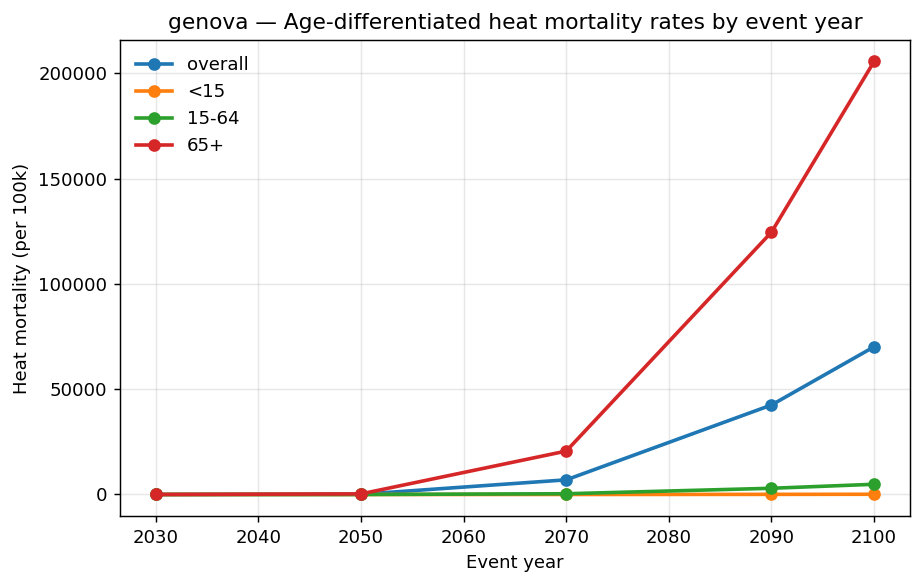

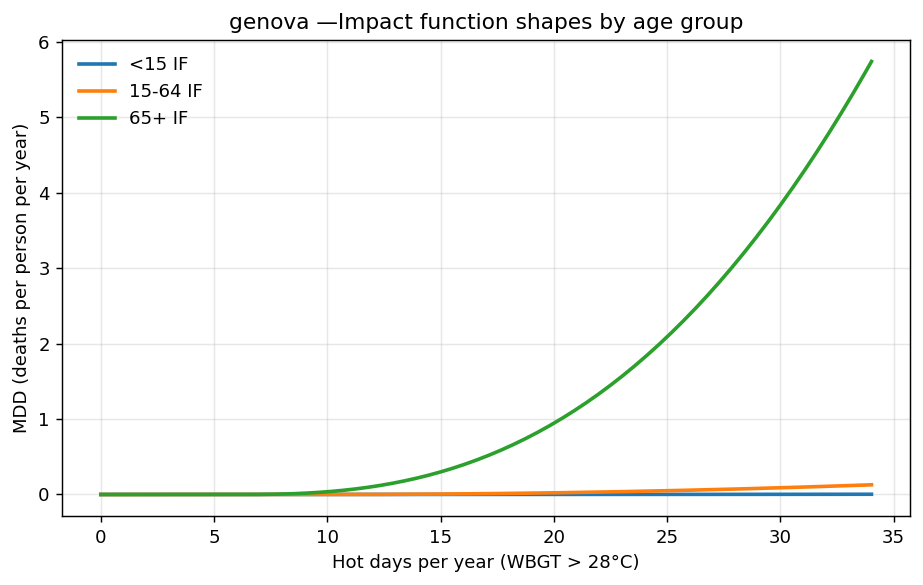

In [30]:
years_list = [int(y) for y in H.event_id.tolist()]
age_keys = ["<15", "15-64", "65+"]

df_rates = pd.DataFrame(
    {
        "overall": np.asarray(rates_all, dtype=float),
        "<15":     np.asarray(by_age["<15"]["per100k"], dtype=float),
        "15-64":   np.asarray(by_age["15-64"]["per100k"], dtype=float),
        "65+":     np.asarray(by_age["65+"]["per100k"], dtype=float),
    },
    index=years_list,
).sort_index()

# Plot 1: per-100k over events
plt.figure(figsize=(7.2, 4.6))
for col in ["overall"] + age_keys:
    plt.plot(df_rates.index.values, df_rates[col].values,
             marker="o", linewidth=2.0, label=col)
plt.xlabel("Event year")
plt.ylabel("Heat mortality (per 100k)")
plt.title(f"{CITY} — Age-differentiated heat mortality rates by event year")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Plot 2: IF shapes (MDD curves)
plt.figure(figsize=(7.2, 4.6))
for k in age_keys:
    f = age_ifs[k]
    plt.plot(f.intensity, f.mdd, linewidth=2.0, label=f"{k} IF")
plt.xlabel("Hot days per year (WBGT > 28°C)")
plt.ylabel("MDD (deaths per person per year)")
plt.title(f"{CITY} —Impact function shapes by age group")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

> **Impact Funtions in Climada:**
> - The first plot shows expected heat mortality per 100k people, by year/event. It rises sharply with hotter futures (2030 → 2100).
> - The elderly group (65+) dominates both in rate and in absolute number of deaths. Working-age adults (15–64) are lower, children are tiny in absolute numbers.
> - The second plot shows the impact functions (IFs). They are increasing, convex curves: more extremely hot days means sharply higher annual heat mortality per person. The elderly curve starts “hurting” after fewer extreme days and climbs faster.

In [31]:
# Summary 
cfg_if       = (cfg or {}).get("impact_functions", {})
age_keys     = list(cfg_if.get("age_params", {}).keys())      
REPORT_YEAR  = int(cfg_if.get("report_year", ANCHOR_EVENT))   

# recomputing
totals_all, rates_all = run_and_rates(exp, H, age_ifs)
by_age = run_by_age(exp, H, age_ifs)

# locating event_row for report year 
years_list = [int(y) for y in H.event_id.tolist()]
try:
    irep = years_list.index(REPORT_YEAR)
except ValueError:
    irep = int(np.argmin([abs(y - REPORT_YEAR) for y in years_list]))
    REPORT_YEAR = years_list[irep]

base = BASELINE_PER100K  # from YAML

# Shares by age in the report year
shares_by_age = {
    a: (float(by_age[a]["per100k"][irep]) / base[a]) if base[a] > 0 else np.nan
    for a in age_keys
}

# Population-weighted baseline (overall, per 100k)
age_pop_local = exp.gdf.groupby("age_group")["value"].sum().astype(float)
overall_baseline = float(sum(base[a] * (age_pop_local[a] / age_pop_local.sum()) for a in age_keys))
overall_share    = float(rates_all[irep]) / overall_baseline if overall_baseline > 0 else np.nan

# some prints (city-agnostic)
print(f"{CITY}: heat shares in {REPORT_YEAR} by age:", {k: float(v) for k, v in shares_by_age.items()})
print(f"{CITY}: overall baseline per 100k = {overall_baseline:.3f}")
print(f"{CITY}: overall heat share in {REPORT_YEAR} = {overall_share:.3f}")

# summary table using YAML 
out = []
for a in age_keys:
    rate = float(by_age[a]["per100k"][irep])
    tot  = float(by_age[a]["totals"][irep])
    out.append({
        "age": a,
        "baseline_allcause_per100k": float(base[a]),
        f"heat_per100k_{REPORT_YEAR}": rate,
        "heat_share": rate / base[a] if base[a] > 0 else np.nan,
        f"heat_deaths_{REPORT_YEAR}": tot,
    })

out.append({
    "age": "overall",
    "baseline_allcause_per100k": overall_baseline,
    f"heat_per100k_{REPORT_YEAR}": float(rates_all[irep]),
    "heat_share": overall_share,
    f"heat_deaths_{REPORT_YEAR}": float(totals_all[irep]),
})

df_summary = pd.DataFrame(out)
display(df_summary)

genova: heat shares in 2050 by age: {'<15': 0.0, '15-64': 2.9304002621127704e-06, '65+': 0.0888363954380073}
genova: overall baseline per 100k = 1065.155
genova: overall heat share in 2050 = 0.085


,age,baseline_allcause_per100k,heat_per100k_2050,heat_share,heat_deaths_2050
0,<15,1.700000,0.000000,0.000000,0.000000
1,15-64,70.000000,0.000205,0.000003,0.000684
2,65+,3129.000000,277.969081,0.088836,522.280113
3,overall,1065.154962,91.000000,0.085434,522.280797


> **Interpretation:**
> - “baseline_allcause_per100k” is: if we take all deaths (not just heat), how many people per 100k die in that age group in a typical year.
> - “heat_per100k_2050” is: according to our hazard (WBGT>28°C days) and IF, how many of those deaths are caused by heat in the 2050 climate.
> - “heat_share” is the share of all deaths that we attribute to heat.
> - “heat_deaths_2050” is absolute expected heat deaths in that age group in Rome FUA-equivalent area.

In [32]:
import json
from pathlib import Path

IF_FREEZE = {
    k: {
        "id": int(f.id) if getattr(f, "id", None) is not None else None,
        "name": getattr(f, "name", k),
        "intensity": np.asarray(f.intensity, float).tolist(),
        "mdd":       np.asarray(f.mdd, float).tolist(),
    }
    for k, f in age_ifs.items()
}

freeze_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
with open(freeze_path, "w") as fh:
    json.dump(IF_FREEZE, fh)
print("Wrote", freeze_path)

Wrote /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/if_curves_frozen_genova.json
